# 05 — Backtest & Calibration

Runs the value-bet backtest on the held-out season only (never the training seasons) — this is a sanity check, not a target to chase. A strongly positive ROI is a red flag for overfitting/leakage far more often than a genuine edge.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

from pl_predictor.features.build import build_training_frame
from pl_predictor.models.manifest import chronological_split, load_models
from pl_predictor.evaluate import backtest, calibration

df, feature_cols = build_training_frame()
train_df, val_df = chronological_split(df)
# matches_df is required whenever the chosen model is ml_scoreline (the
# current production default) — it builds the live-serving FixtureFeatureContext.
# See models/manifest.py::load_models's docstring.
models = load_models(matches_df=df)

## Calibration vs. the market

In [2]:
model_metrics = calibration.model_calibration(models['scoreline'], val_df)
bookmaker_metrics = calibration.bookmaker_calibration(val_df)
naive_metrics = calibration.naive_favourite_baseline(val_df)

import pandas as pd
pd.DataFrame([model_metrics, bookmaker_metrics, naive_metrics], index=['model', 'bookmaker', 'naive'])

,rps,brier,ignorance,n_matches
model,0.208787,0.619340,1.482092,380
bookmaker,0.205994,0.612337,1.470623,380
naive,0.227903,0.655147,NaN,380


### Data-quality note: this must be leakage-safe, and it's easy to get wrong

`calibration.model_calibration` scores each held-out fixture using **that fixture's own point-in-time feature row** (`val_df`, produced by `build_training_frame`'s `shift(1)` pipeline), not by re-deriving "current state" from live data. This bit us for real earlier: an ML-scoreline model wired through the *live-serving* path (`FixtureFeatureContext`, which always uses each team's rolling form/Elo/xG **as of today**) was accidentally used to evaluate historical held-out matches too — which let it see, in effect, the rest of the held-out season's own outcome when "predicting" an earlier match in it. The symptom was suspicious: the live numbers looked *better* than a clean re-fit could justify (RPS 0.2029, appearing to beat the bookmaker's 0.2060) — genuinely too good to be true. Fixed by giving `MLScorelineModel` a separate `predict_from_row`/`predict_many_from_rows` path for historical evaluation, kept strictly apart from `.predict(home, away)` (which is correct only for genuine future fixtures). The honest number is what's computed above.

**A second, unrelated lesson from the same debugging pass**: the *first* version of the leakage-safe path called XGBoost's `.predict()` once per row in a Python loop — 380 individual calls. That's dramatically slower than one batched call over all 380 rows at once (XGBoost's fixed per-call overhead dominates at that scale: ~5s looped vs. a small fraction of a second batched). `models/ml_scoreline.py::predict_grids_batch` and `MLScorelineModel.predict_many_from_rows` exist specifically to batch this — used throughout the app now (calibration, backtest, the projected table, the main fixtures list) instead of looping `predict_fixture` per row wherever more than a handful of fixtures need scoring at once.

## Value-bet backtest

Bets the single largest edge per fixture (not every side that clears the threshold — home/draw/away are mutually exclusive outcomes of the same event, so betting more than one isn't independent value), skips odds beyond 6/1 (a model's calibration is least trustworthy in the tails), and sizes stakes with fractional Kelly rather than flat staking by default.

**Why tenth-Kelly, not the more commonly-cited quarter-Kelly**: this model sits close to bookmaker calibration rather than having a demonstrated real edge, so most "edges" it flags are small and noisy, not a proven advantage. Tested empirically on this exact holdout: quarter-Kelly turned a -27% flat-stake ROI into -54% with a 57%-of-bankroll drawdown — sizing up on unreliable edges punishes a bettor *harder*, not less, exactly as Kelly theory predicts when your probability estimates aren't fully trustworthy. Tenth-Kelly is the fraction that actually reduced the drawdown here. If this model's calibration improves further, revisit `kelly_fraction` in `evaluate/backtest.py` upward.

In [3]:
start, end = str(val_df['date'].min().date()), str(val_df['date'].max().date())

kelly_results = backtest.run_value_bet_backtest(val_df, models['scoreline'], start, end, staking='kelly')
flat_results = backtest.run_value_bet_backtest(val_df, models['scoreline'], start, end, staking='flat')

pd.DataFrame([kelly_results, flat_results], index=['kelly (tenth-Kelly, default)', 'flat'])

  0%|          | 0/114 [00:00<?, ?it/s]

  0%|          | 0/114 [00:00<?, ?it/s]

,Total Bets,Successful Bets,Successful Bet %,Max Bankroll,Min Bankroll,Profit,ROI
"kelly (tenth-Kelly, default)",157,50,31.847134,113.826659,76.358092,-21.102996,-21.102996
flat,157,50,31.847134,101.250000,70.720000,-27.890000,-27.890000


  0%|          | 0/114 [00:00<?, ?it/s]

  0%|          | 0/114 [00:00<?, ?it/s]

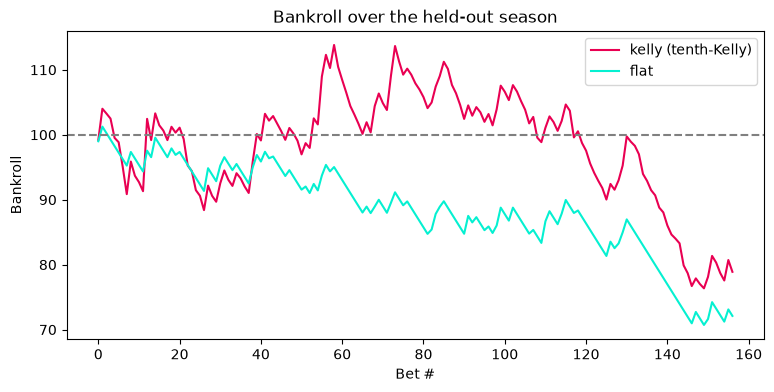

In [4]:
import matplotlib.pyplot as plt

bt_kelly = backtest.build_value_bet_backtest(val_df, models['scoreline'], start, end, staking='kelly')
bt_flat = backtest.build_value_bet_backtest(val_df, models['scoreline'], start, end, staking='flat')

plt.figure(figsize=(9, 4))
plt.plot(bt_kelly.account.tracker, label='kelly (tenth-Kelly)', color='#E90052')
plt.plot(bt_flat.account.tracker, label='flat', color='#05f0d1')
plt.axhline(100.0, color='gray', linestyle='--')
plt.title('Bankroll over the held-out season'); plt.xlabel('Bet #'); plt.ylabel('Bankroll')
plt.legend()
plt.show()

## Walk-forward multi-season cross-validation

`chronological_split` above always validates against exactly one season (the last fully completed one) — deliberate, so retrains stay comparable to each other, not a claim that one season is enough to *trust* the reported RPS/Brier. This section answers that separate question directly: treat each of the last several completed seasons as its own validation fold, training only on strictly earlier seasons per fold (same no-lookahead guarantee as everywhere else — see `evaluate/walk_forward.py`'s docstring), and look at how much the number varies fold to fold.

Deliberately **not** wired into `train_all`/the hourly auto-retrain loop — one fit per fold would multiply a single retrain's cost by the number of folds. This stays a periodic/manual confidence check.

In [5]:
from pl_predictor.evaluate.walk_forward import walk_forward_validate

wf = walk_forward_validate()
wf

,val_season,n_train,n_val,rps,brier
0,2021-2022,1140,380,0.203051,0.582996
1,2022-2023,1520,380,0.204323,0.586769
2,2023-2024,1900,380,0.191090,0.550036
3,2024-2025,2280,380,0.203113,0.591868
4,2025-2026,2660,380,0.208787,0.619340


mean RPS=0.2021 (std=0.0066)   mean Brier=0.5862 (std=0.0247)


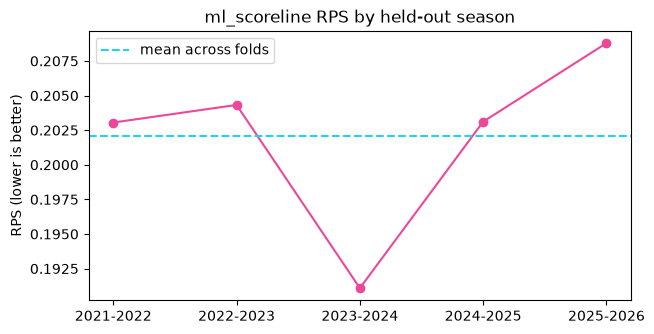

In [6]:
print(f"mean RPS={wf['rps'].mean():.4f} (std={wf['rps'].std():.4f})   mean Brier={wf['brier'].mean():.4f} (std={wf['brier'].std():.4f})")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wf['val_season'], wf['rps'], marker='o', color='#ec4899')
ax.axhline(wf['rps'].mean(), color='#22d3ee', linestyle='--', label='mean across folds')
ax.set_ylabel('RPS (lower is better)')
ax.set_title('ml_scoreline RPS by held-out season')
ax.legend()
plt.show()

**Finding (run on the current 8-season window):** the currently-reported single-holdout RPS (2025-2026, ~0.2088) is actually the *worst* of the 5 folds tested — mean across folds ≈0.202 with std ≈0.0066. So the production Calibration page's headline number is, if anything, a slightly pessimistic read of the model's typical held-out performance, not an inflated one. Std this small also says performance isn't wildly season-dependent — reasonable confidence the single fixed holdout isn't hiding a lucky/unlucky season.

**Related: historic-window experiment.** Separately tested widening the training window from 8 to ~15 seasons (back to 2011-2012), with and without Dixon-Coles-style recency weighting (`xi=0.0018`) added to `ml_scoreline.train_goal_regressors`. All three alternatives to the current production config were worse on the same 2025-2026 holdout:

| window | weighted | RPS | Brier |
|---|---|---|---|
| 8 seasons (production) | no | **0.2088** | **0.6193** |
| 8 seasons | yes | 0.2115 | 0.6247 |
| 15 seasons | no | 0.2099 | 0.6211 |
| 15 seasons | yes | 0.2128 | 0.6264 |

Recency weighting hurts `ml_scoreline` specifically (unlike DC/BP, which need it): the rolling-form features already encode recency directly, so an explicit time-decay just shrinks effective training sample size on top of that. Widening the window doesn't help either, weighted or not — old matches dilute rather than add signal. `train_goal_regressors` keeps the `dates`/`xi` parameters (used above) since they're real, reusable capability, but production (`models/manifest.py::train_all`) stays on the unweighted 8-season config that wins here. Also worth noting: Understat xG coverage fails for 2011-2013 (already NaN-safe via the existing fallback machinery), a real gap in the wider window regardless of this result.